# Weather IoT Anomaly Detection (Python)

This notebook is a Python translation of your R workflow: EDA, preprocessing, LSTM autoencoder training, anomaly detection, and reporting.

In [1]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn tensorflow

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached narwhals-2.20.0-py3-none-any.whl.metadata (15 kB)
  Usi

In [2]:
import os
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU devices: []


In [ ]:
# Set your dataset path here
# Example Kaggle path:
# csv_path = '/kaggle/input/weather-long-term-time-series-forecasting/cleaned_weather.csv'
csv_path = 'archive\cleaned_weather.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(f'Dataset not found at: {csv_path}')

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(52696, 21)


,date,p,T,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,...,rho,wv,max. wv,wd,rain,raining,SWDR,PAR,max. PAR,Tlog
0,2020-01-01 00:10:00,1008.89,0.71,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,...,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,2020-01-01 00:20:00,1008.76,0.75,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,...,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,2020-01-01 00:30:00,1008.66,0.73,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,...,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,2020-01-01 00:40:00,1008.64,0.37,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,...,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,2020-01-01 00:50:00,1008.61,0.33,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,...,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [4]:
print('Shape:', df.shape)
print('Missing values by column:')
print(df.isna().sum())

df.info()

Shape: (52696, 21)
Missing values by column:
date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      52696 non-null  str    
 1   p         52696 non-null  float64
 2   T         52696 non-null  float64
 3   Tpot      52696 non-null  float64
 4   Tdew      52696 non-null  float64
 5   rh        52696 non-null  float64
 6   VPmax     52696 non-null  float64
 7   VPact     52696 non-null  float64
 8   VPdef     52696 non-null  float64
 9   sh        52696 non-null  float64
 10  H2OC      52696 non-null  float64
 11  rho       52696 non-null  float64
 12 

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,52696,52695,2020-05-12 06:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p,52696.0,NaN,NaN,NaN,989.989233,9.207149,955.58,984.8,990.92,995.93,1020.07
T,52696.0,NaN,NaN,NaN,10.818241,7.468671,-6.44,4.59,10.23,16.18,34.8
Tpot,52696.0,NaN,NaN,NaN,284.796938,7.616995,266.19,278.55,284.32,290.26,309.13
Tdew,52696.0,NaN,NaN,NaN,5.409105,5.956722,-13.81,0.7775,5.26,9.7,20.5
rh,52696.0,NaN,NaN,NaN,72.487133,19.23026,21.16,58.82,75.4,87.9,100.0
VPmax,52696.0,NaN,NaN,NaN,14.487046,7.63296,3.77,8.48,12.48,18.42,55.67
VPact,52696.0,NaN,NaN,NaN,9.676828,4.023504,2.09,6.46,8.89,12.05,24.16
VPdef,52696.0,NaN,NaN,NaN,4.810131,5.53932,0.0,1.17,2.74,6.44,42.1
sh,52696.0,NaN,NaN,NaN,6.111159,2.561536,1.3,4.07,5.61,7.62,15.4


In [6]:
# Date parsing + derived time features
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name().str[:3]
df['day'] = df['date'].dt.dayofyear
df['hour'] = df['date'].dt.hour

# Similar to R make.names to keep downstream references safe
def make_names(col):
    col = re.sub(r'[^0-9A-Za-z_.]', '.', str(col))
    if re.match(r'^[0-9]', col):
        col = 'X' + col
    return col

df.columns = [make_names(c) for c in df.columns]

all_vars = [c for c in df.columns if c not in ['date', 'year', 'month', 'day', 'hour']]
key_vars = ['T', 'rh', 'wv', 'rain', 'SWDR', 'PAR']

print('Total variables for analysis:', len(all_vars))
print('Key variables present:', [k for k in key_vars if k in df.columns])

Total variables for analysis: 20
Key variables present: ['T', 'rh', 'wv', 'rain', 'SWDR', 'PAR']


## Time Series Plot Function

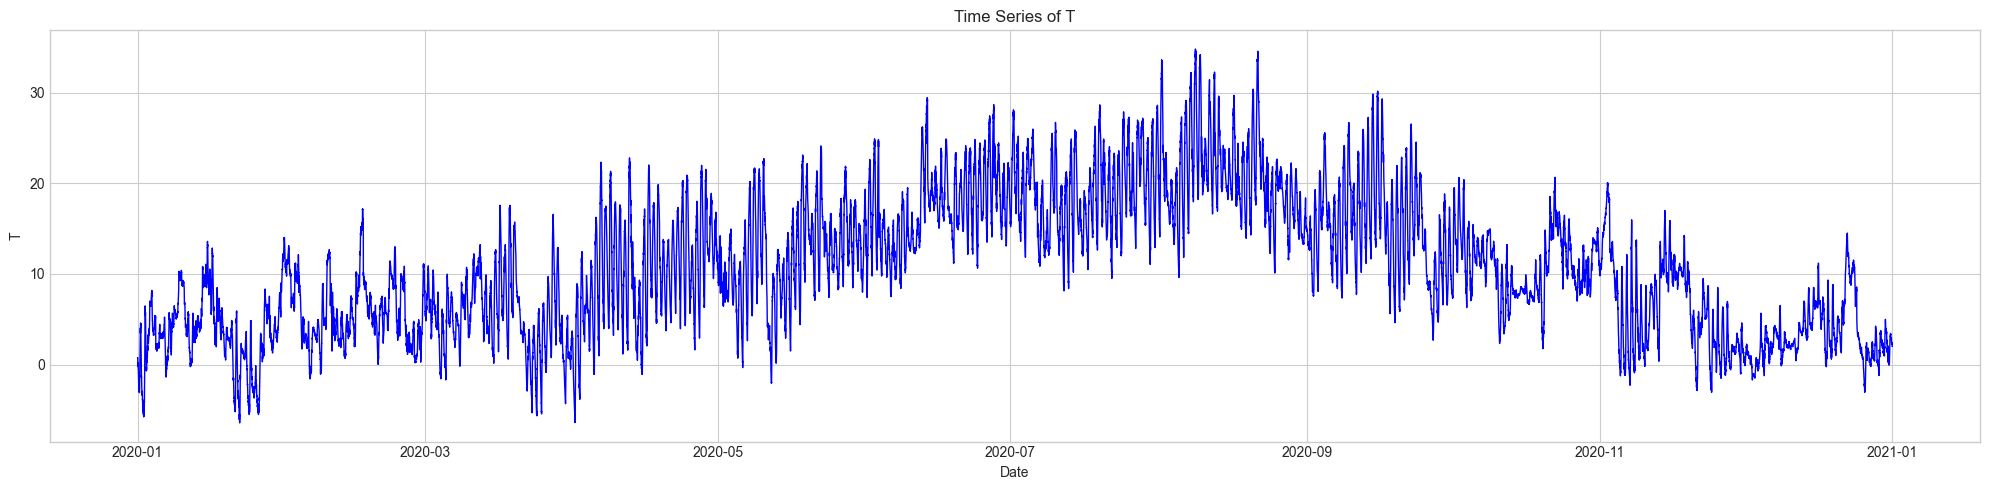

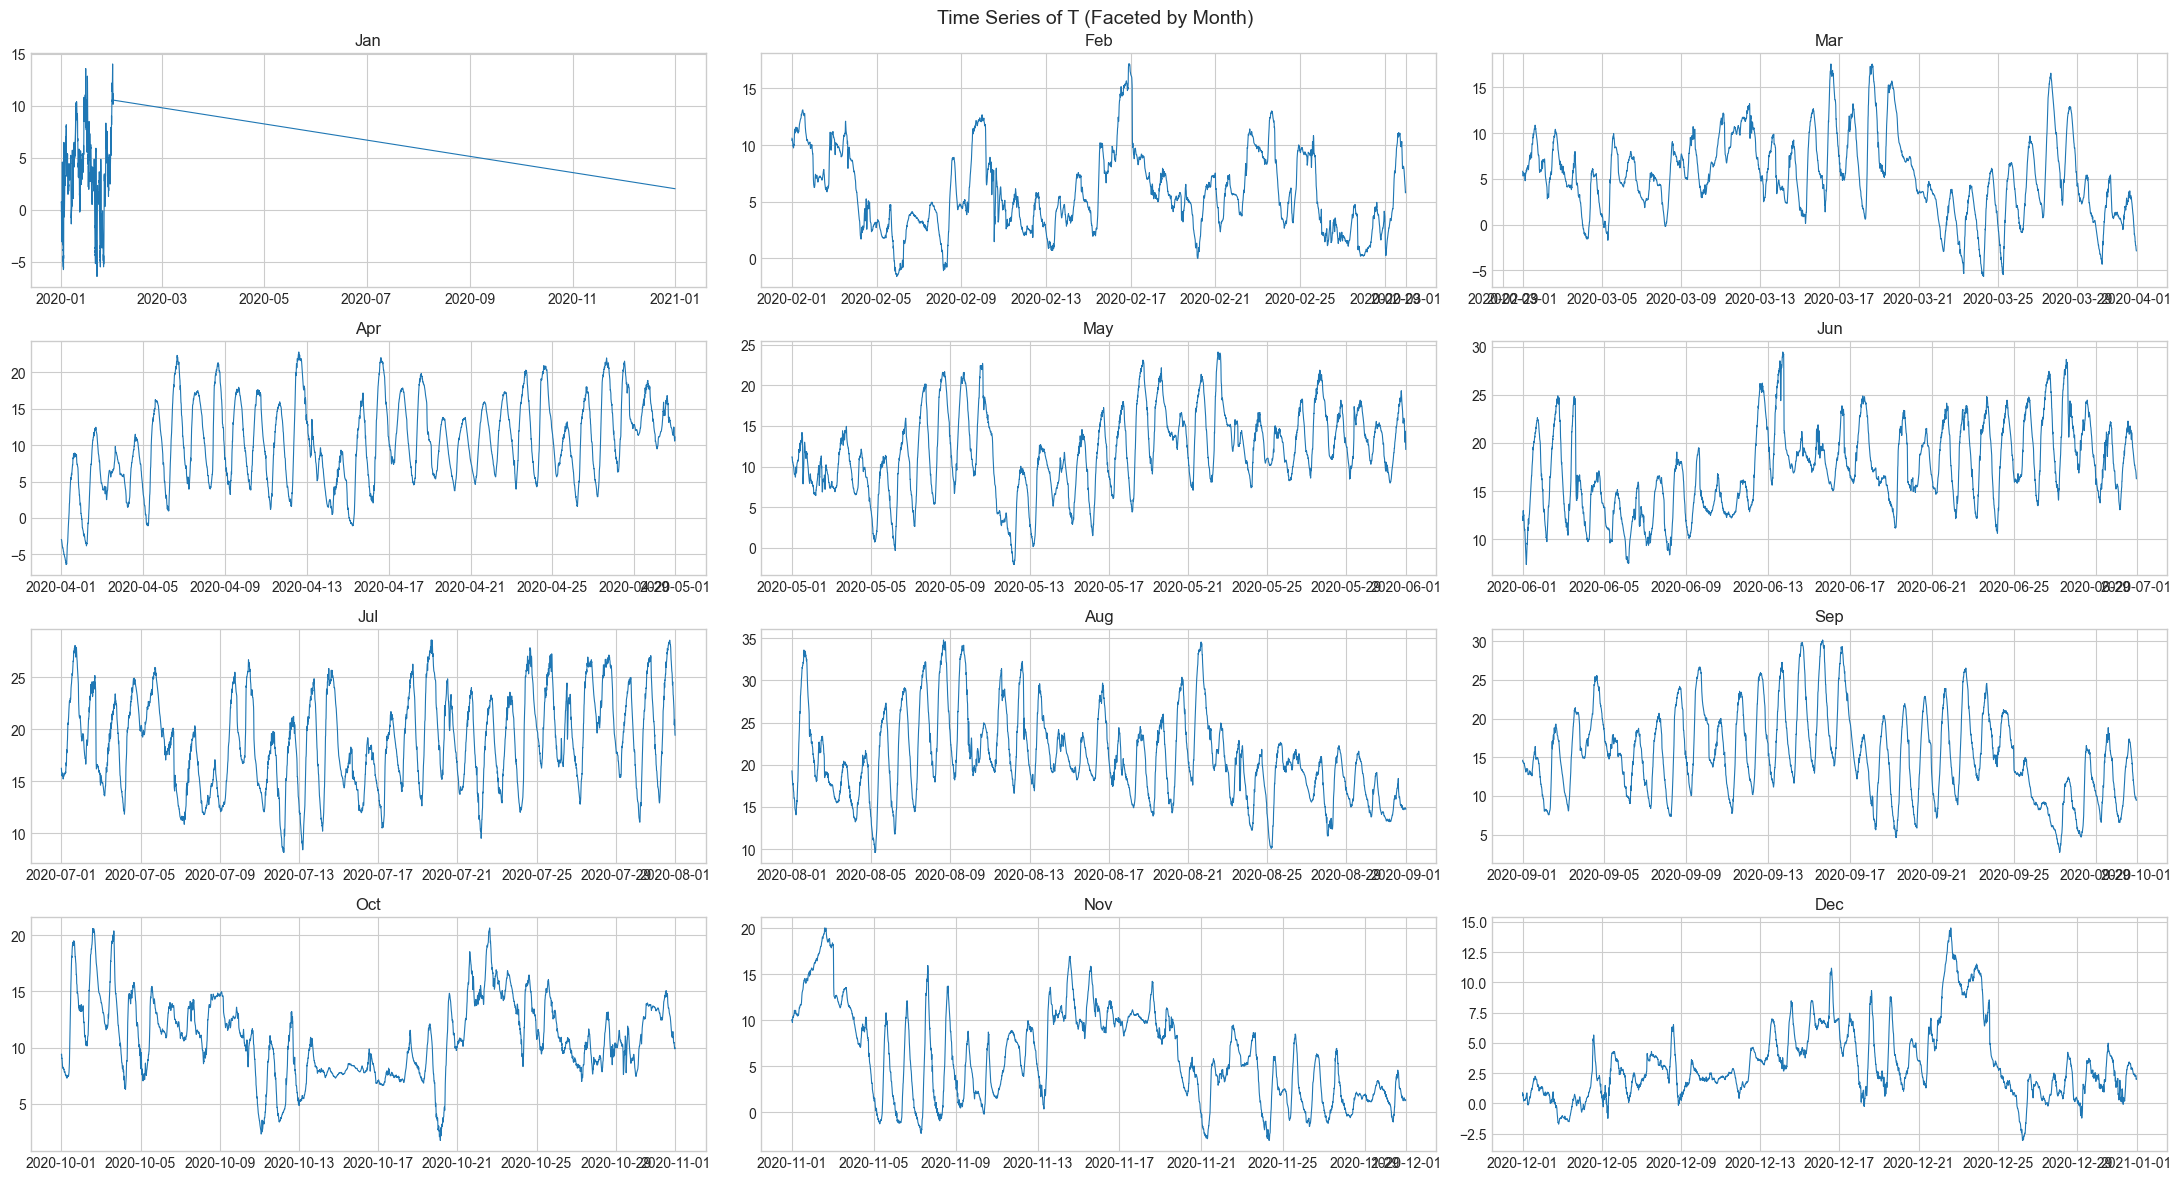

In [7]:
def plot_time_series(data, var, title=None, y_label=None):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return

    title = title or f'Time Series of {var}'
    y_label = y_label or var

    plt.figure(figsize=(20, 5))
    plt.plot(data['date'], data[var], color='blue', linewidth=1)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

    months = pd.Categorical(data['month'], categories=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], ordered=True)
    plot_df = data.copy()
    plot_df['month'] = months

    fig, axes = plt.subplots(4, 3, figsize=(22, 12), sharey=False)
    axes = axes.flatten()

    for i, m in enumerate(months.categories):
        ax = axes[i]
        mdf = plot_df[plot_df['month'] == m]
        if len(mdf) > 0:
            ax.plot(mdf['date'], mdf[var], linewidth=0.8)
            ax.set_title(m)
        else:
            ax.set_visible(False)

    plt.suptitle(f'{title} (Faceted by Month)', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_time_series(df, 'T', title='Time Series of T', y_label='T')

## Boxplot by Month

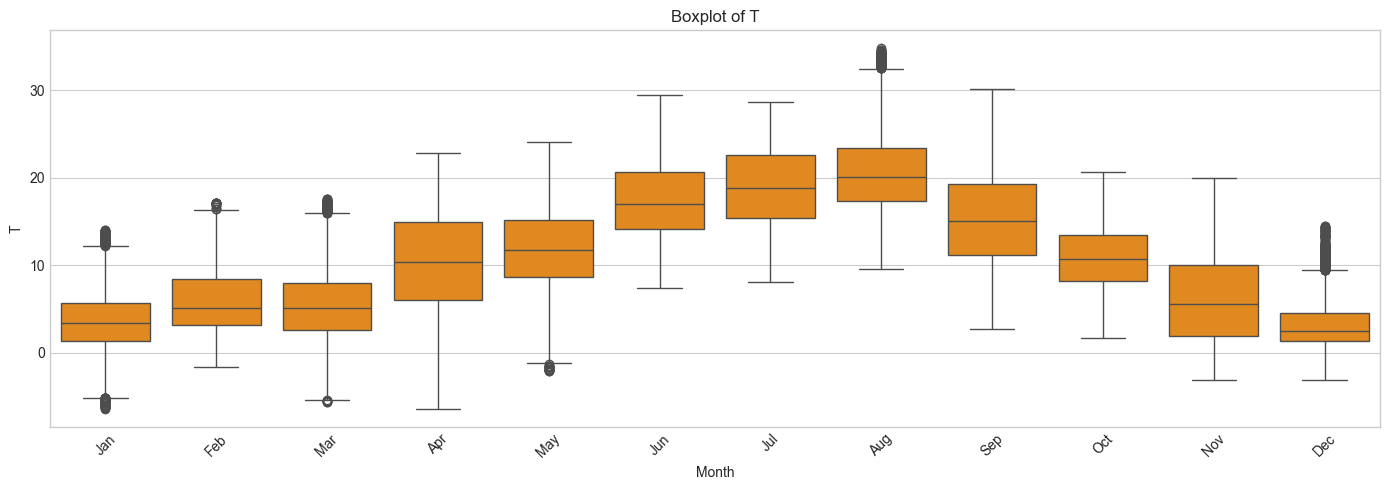

In [8]:
def plot_boxplot(data, var):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=data, x='month', y=var, color='darkorange')
    plt.title(f'Boxplot of {var}')
    plt.xlabel('Month')
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_boxplot(df, 'T')

## Histogram by Month

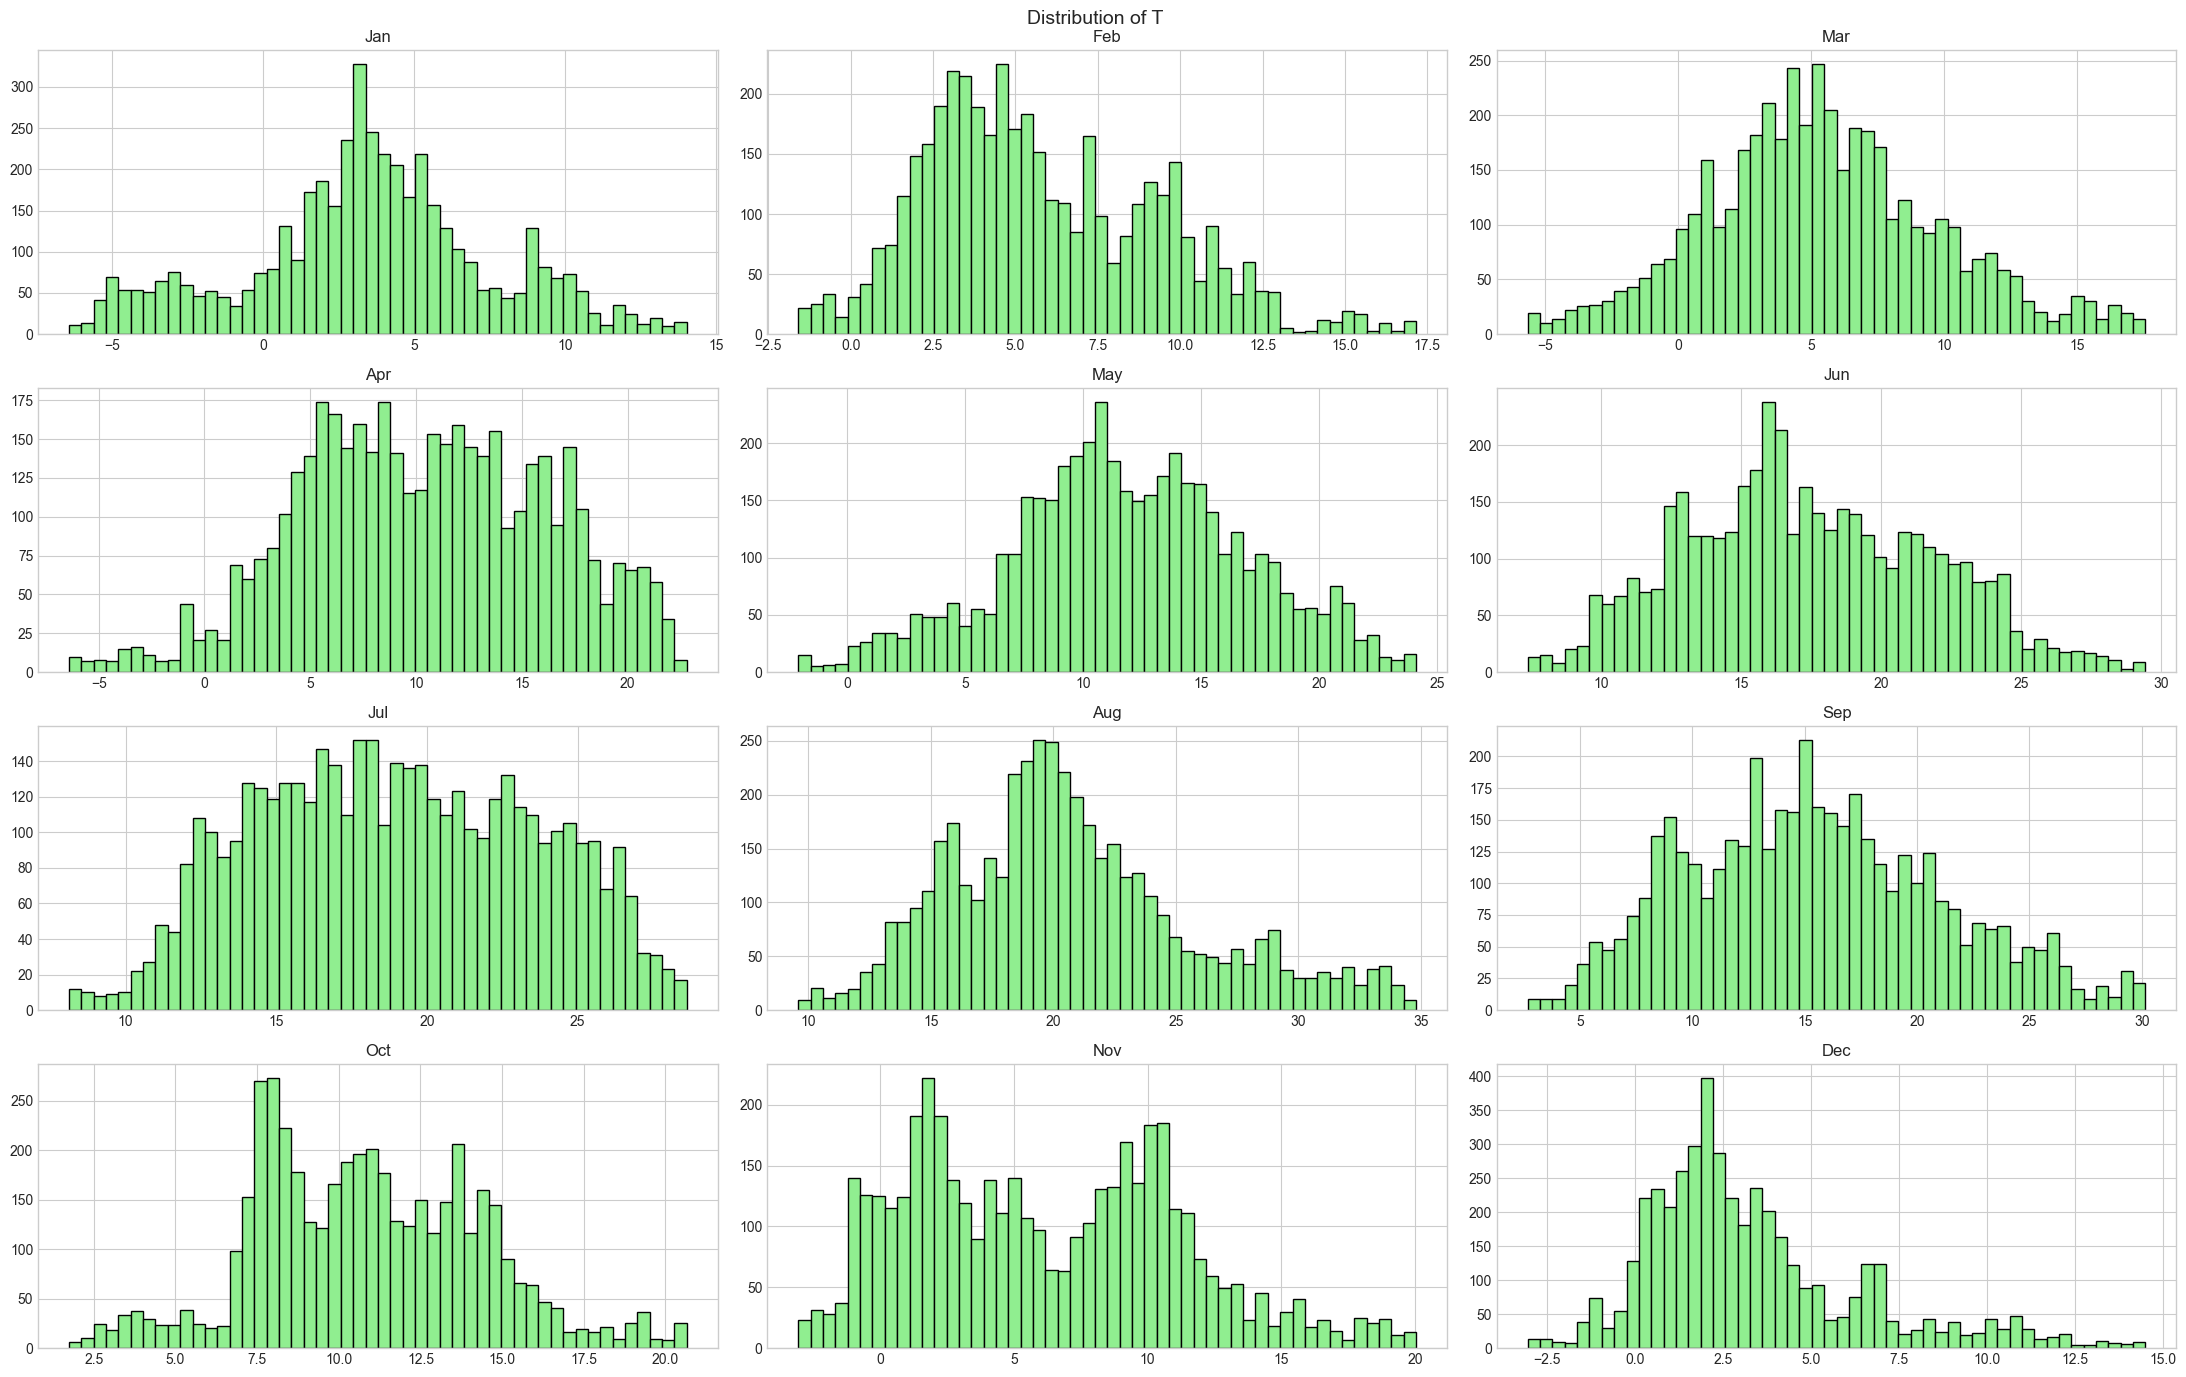

In [9]:
def plot_histogram(data, var, bins=50):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return

    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    fig, axes = plt.subplots(4, 3, figsize=(22, 14), sharex=False, sharey=False)
    axes = axes.flatten()

    for i, m in enumerate(months):
        ax = axes[i]
        mdf = data[data['month'] == m]
        if len(mdf) > 0:
            ax.hist(mdf[var].dropna(), bins=bins, color='lightgreen', edgecolor='black')
            ax.set_title(m)
        else:
            ax.set_visible(False)

    plt.suptitle(f'Distribution of {var}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_histogram(df, 'T')

## Correlation Matrix

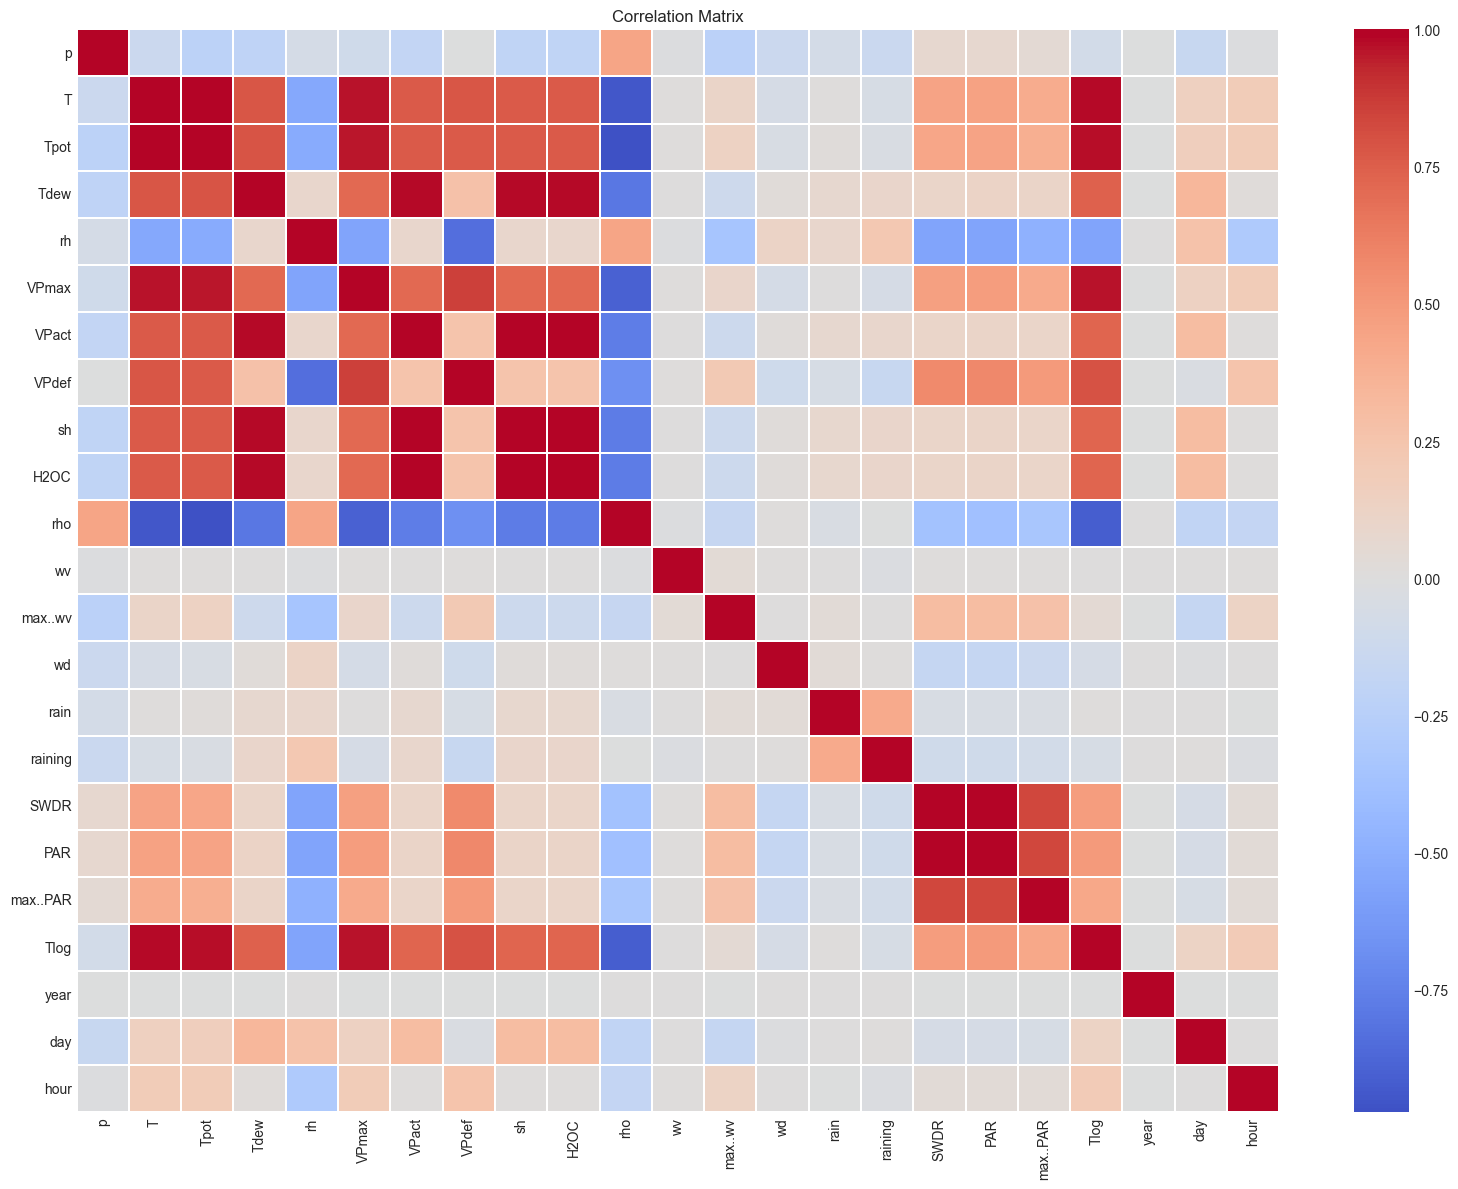

In [10]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Heatmap for a Single Variable

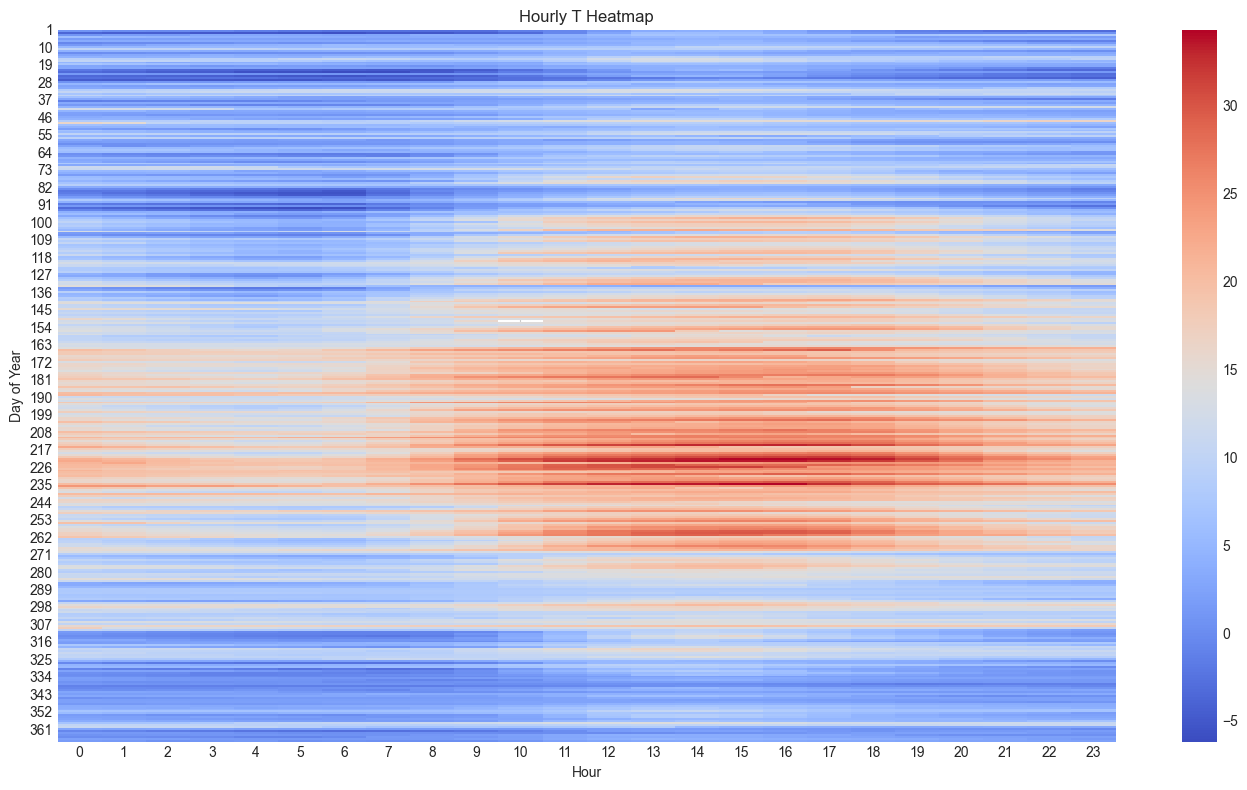

In [11]:
def plot_heatmap(data, var):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return

    heatmap_data = (
        data.groupby(['day', 'hour'], as_index=False)[var]
        .mean()
        .rename(columns={var: 'mean_value'})
    )

    pivot = heatmap_data.pivot(index='day', columns='hour', values='mean_value')

    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, cmap='coolwarm')
    plt.title(f'Hourly {var} Heatmap')
    plt.xlabel('Hour')
    plt.ylabel('Day of Year')
    plt.tight_layout()
    plt.show()

plot_heatmap(df, 'T')

## Anomaly Highlight Plot

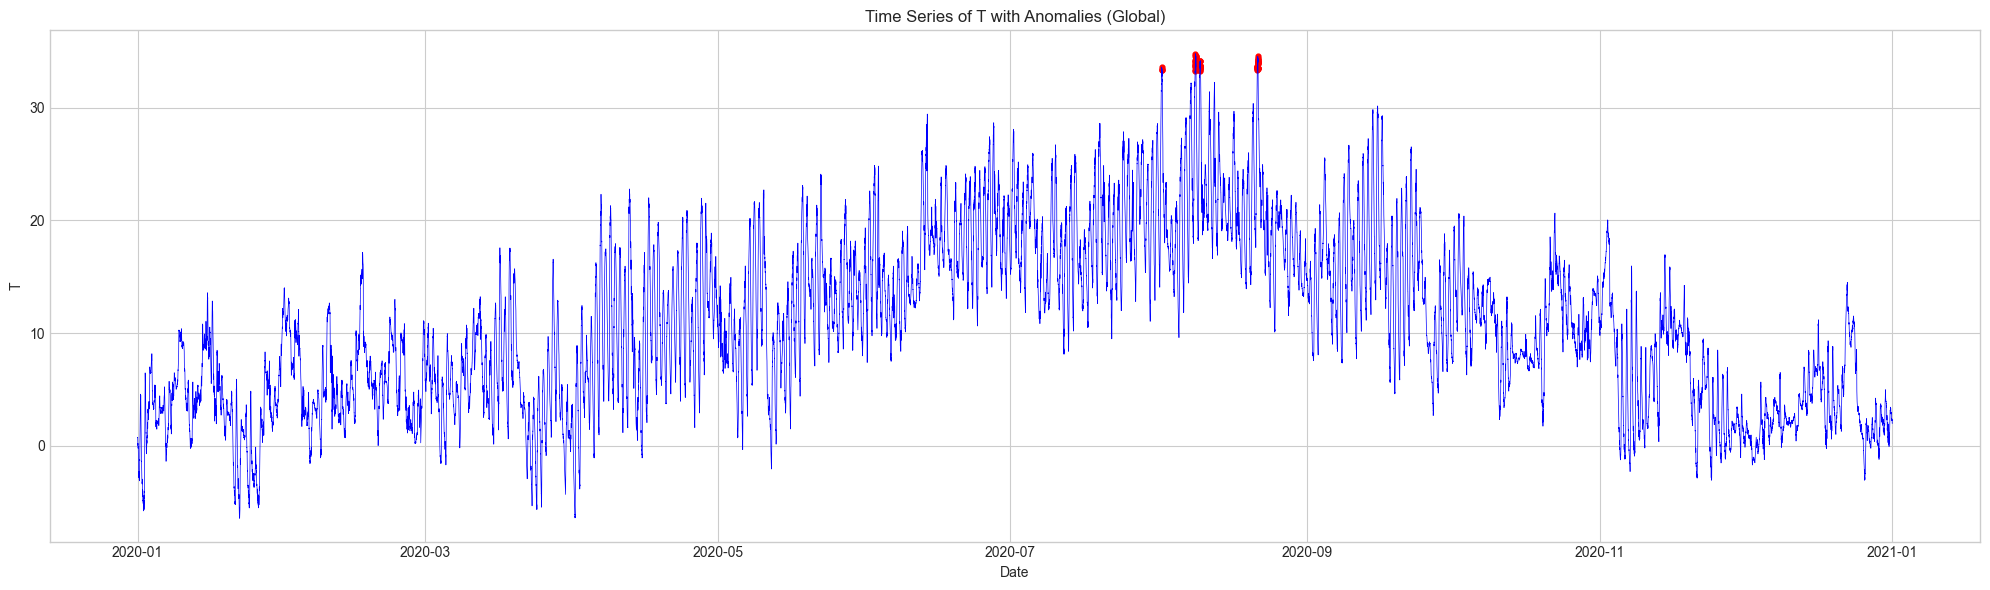

In [12]:
def plot_anomaly_highlight_global(data, var):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return

    tmp = data.copy()
    mean_val = tmp[var].mean()
    sd_val = tmp[var].std()
    tmp['anomaly'] = (tmp[var] - mean_val).abs() > (3 * sd_val)

    plt.figure(figsize=(20, 6))
    plt.plot(tmp['date'], tmp[var], color='blue', linewidth=0.5)
    a = tmp[tmp['anomaly']]
    plt.scatter(a['date'], a[var], color='red', s=12)
    plt.title(f'Time Series of {var} with Anomalies (Global)')
    plt.xlabel('Date')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

plot_anomaly_highlight_global(df, 'T')

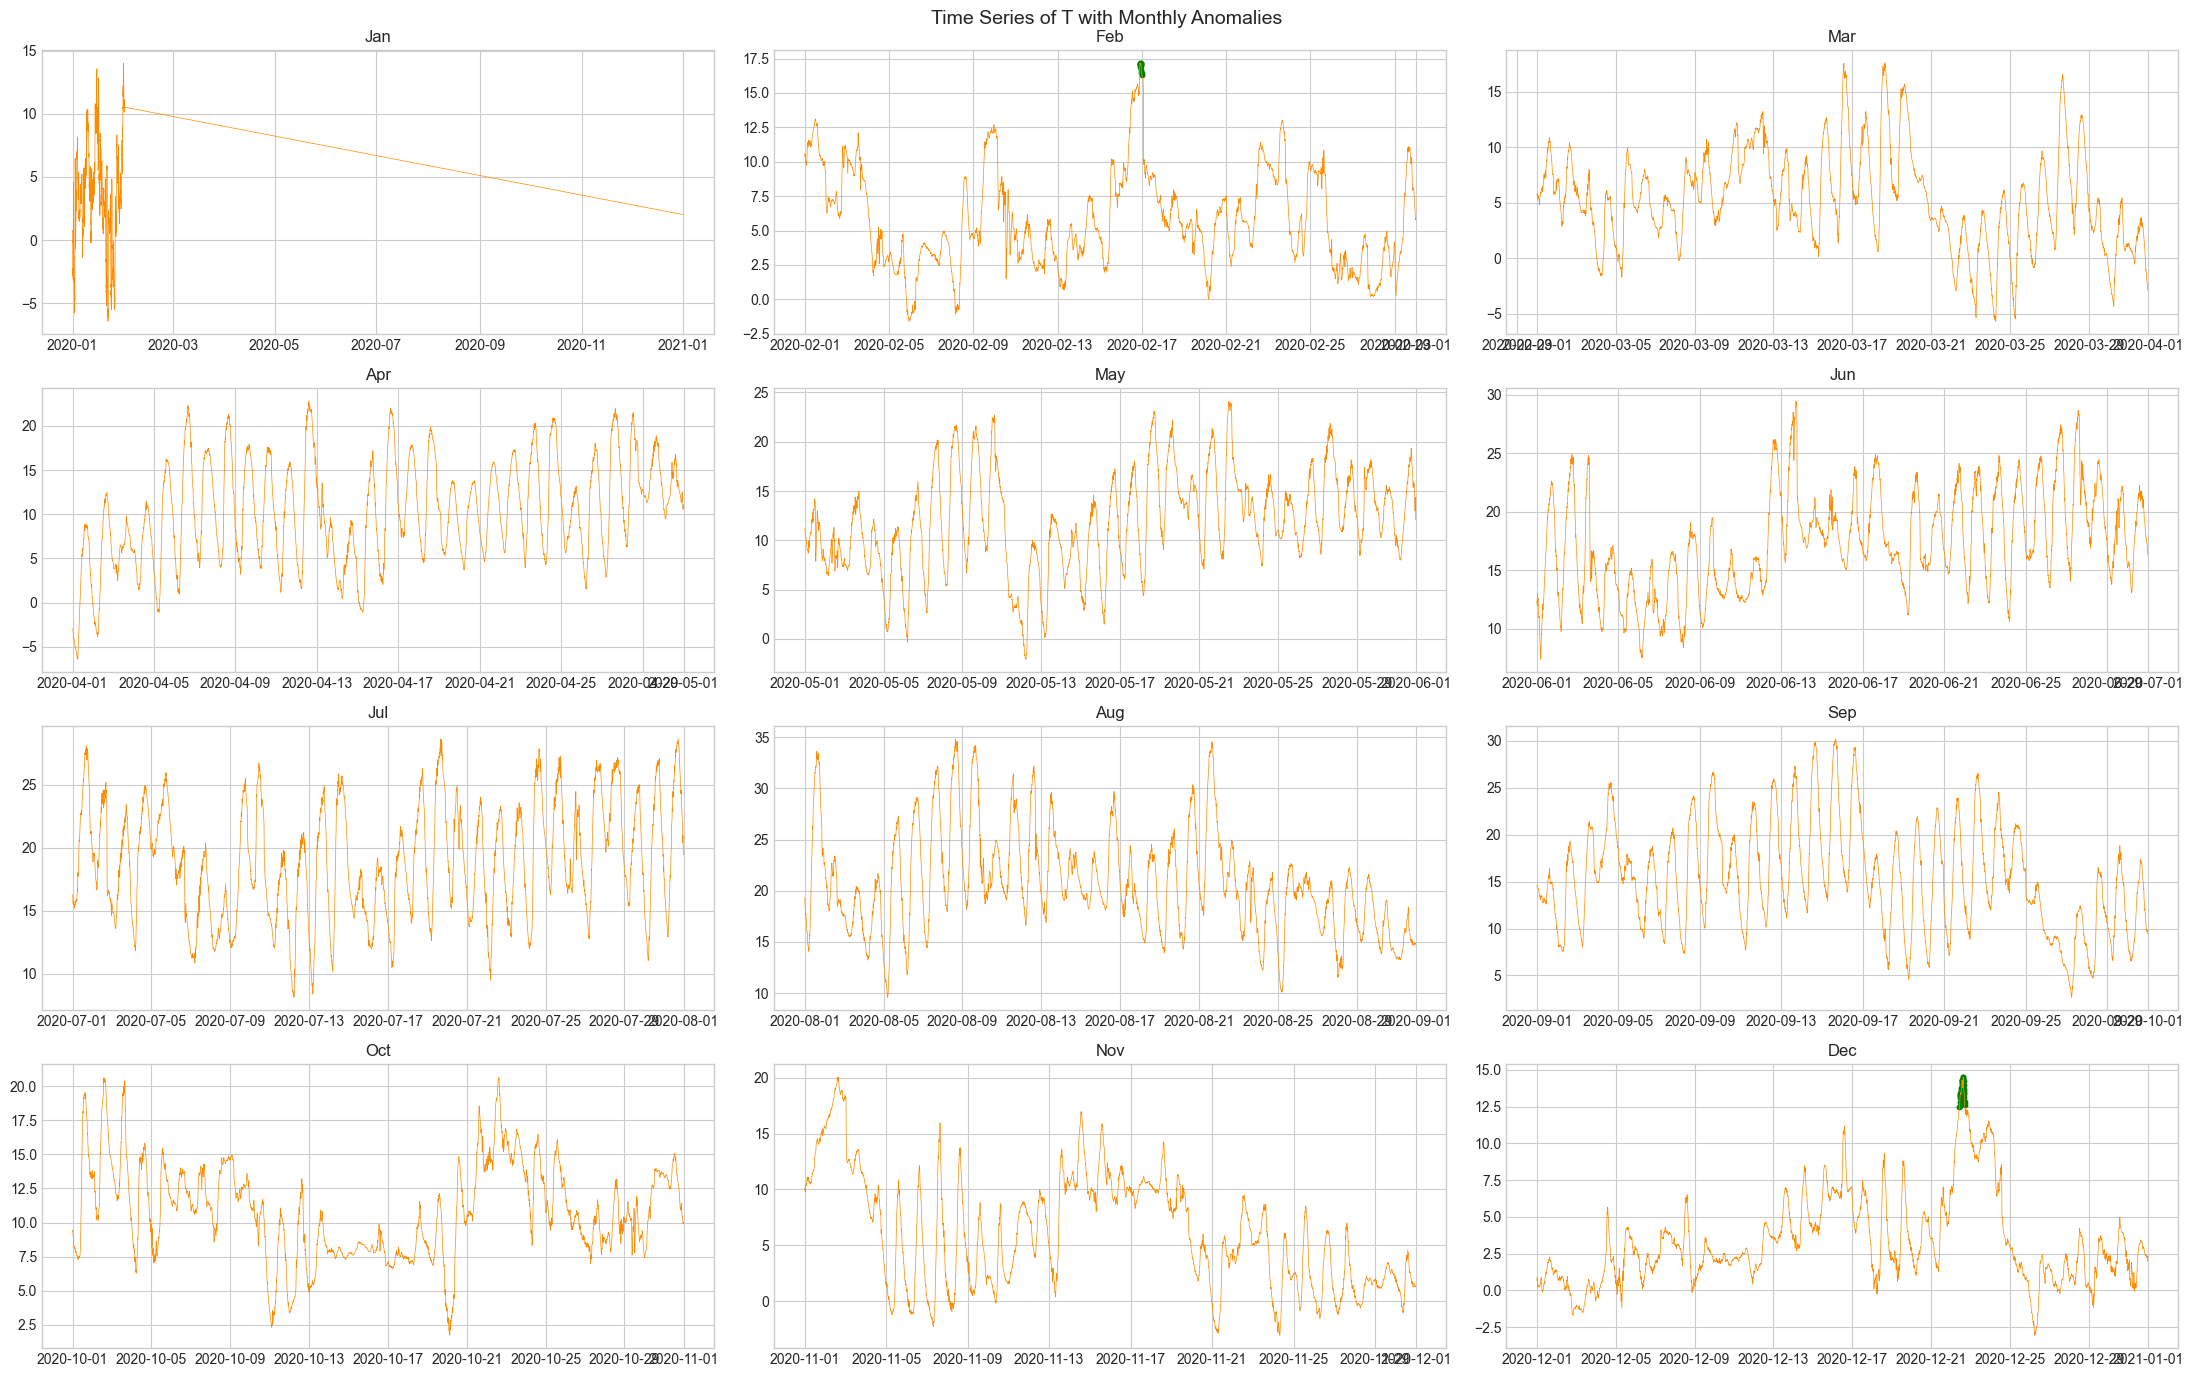

In [13]:
def plot_anomaly_highlight_monthly(data, var):
    if var not in data.columns or not np.issubdtype(data[var].dropna().dtype, np.number):
        print(f'Skipping {var}: not numeric or not found.')
        return

    tmp = data.copy()
    grp = tmp.groupby('month')[var]
    mean_by_m = grp.transform('mean')
    sd_by_m = grp.transform('std')
    tmp['anomaly'] = (tmp[var] - mean_by_m).abs() > (3 * sd_by_m)

    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    fig, axes = plt.subplots(4, 3, figsize=(22, 14), sharey=False)
    axes = axes.flatten()

    for i, m in enumerate(months):
        ax = axes[i]
        mdf = tmp[tmp['month'] == m]
        if len(mdf) > 0:
            ax.plot(mdf['date'], mdf[var], color='darkorange', linewidth=0.5)
            a = mdf[mdf['anomaly']]
            ax.scatter(a['date'], a[var], color='green', s=10)
            ax.set_title(m)
        else:
            ax.set_visible(False)

    plt.suptitle(f'Time Series of {var} with Monthly Anomalies', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_anomaly_highlight_monthly(df, 'T')

## Modeling Data Preparation

In [14]:
df_model_base = df.copy()

# Keep date-safe columns and build model frames
sensor_cols = [
    'Tpot', 'Tdew', 'rh', 'VPmax', 'VPact', 'VPdef', 'sh',
    'H2OC', 'rho', 'wv', 'max..wv', 'wd', 'rain', 'raining',
    'SWDR', 'PAR', 'max..PAR', 'Tlog'
]

missing_sensor_cols = [c for c in sensor_cols if c not in df_model_base.columns]
if missing_sensor_cols:
    raise ValueError(f'Missing expected sensor columns: {missing_sensor_cols}')

df_model = df_model_base[sensor_cols].copy()
df_plot = df_model_base[['year', 'month', 'day', 'hour'] + sensor_cols].copy()
df_plot = df_plot.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)

df_plot.to_csv('data_with_time.csv', index=False)
print('data_with_time.csv saved!')
df_model.head()

data_with_time.csv saved!


,Tpot,Tdew,rh,VPmax,VPact,VPdef,sh,H2OC,rho,wv,max..wv,wd,rain,raining,SWDR,PAR,max..PAR,Tlog
0,273.18,-1.33,86.1,6.43,5.54,0.89,3.42,5.49,1280.62,1.02,1.60,224.3,0.0,0.0,0.0,0.0,0.0,11.45
1,273.22,-1.44,85.2,6.45,5.49,0.95,3.39,5.45,1280.33,0.43,0.84,206.8,0.0,0.0,0.0,0.0,0.0,11.51
2,273.21,-1.48,85.1,6.44,5.48,0.96,3.39,5.43,1280.29,0.61,1.48,197.1,0.0,0.0,0.0,0.0,0.0,11.60
3,272.86,-1.64,86.3,6.27,5.41,0.86,3.35,5.37,1281.97,1.11,1.48,206.4,0.0,0.0,0.0,0.0,0.0,11.70
4,272.82,-1.50,87.4,6.26,5.47,0.79,3.38,5.42,1282.08,0.49,1.40,209.6,0.0,0.0,0.0,0.0,0.0,11.81


In [15]:
# Scale sensor data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_model.values)

SEQ_LEN = 60
N_FEATURES = data_scaled.shape[1]

def create_sequences(data, seq_len):
    n = data.shape[0]
    seqs = np.zeros((n - seq_len, seq_len, data.shape[1]), dtype=np.float32)
    for i in range(n - seq_len):
        seqs[i] = data[i:i + seq_len]
    return seqs

sequences = create_sequences(data_scaled, SEQ_LEN)
print('Sequences shape:', sequences.shape)

Sequences shape: (52636, 60, 18)


## Train/Validation Split

In [16]:
split_idx = int(0.8 * sequences.shape[0])
x_train = sequences[:split_idx]
x_val = sequences[split_idx:]

print('x_train:', x_train.shape)
print('x_val:', x_val.shape)

x_train: (42108, 60, 18)
x_val: (10528, 60, 18)


## LSTM Autoencoder Model

In [17]:
model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, N_FEATURES)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(16, return_sequences=False),
    layers.RepeatVector(SEQ_LEN),
    layers.LSTM(16, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=True),
    layers.Dense(N_FEATURES)
])

learning_rate = 0.001
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mae')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60, 18)         │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,450 (197.07 KB)

 Trainable params: 50,450 (197.07 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
print(f'Input shape: (batch, {SEQ_LEN}, {N_FEATURES})')
print(f'Output shape: (batch, {SEQ_LEN}, {N_FEATURES})')

start_time = time.time()
history = model.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    epochs=100,
    batch_size=32,
    verbose=2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)
training_time = time.time() - start_time
print(f'Training time: {training_time:.2f} seconds')

Input shape: (batch, 60, 18)
Output shape: (batch, 60, 18)
Epoch 1/100
1316/1316 - 77s - 58ms/step - loss: 0.2838 - val_loss: 0.1723
Epoch 2/100
1316/1316 - 80s - 61ms/step - loss: 0.2147 - val_loss: 0.1453
Epoch 3/100
1316/1316 - 106s - 81ms/step - loss: 0.1901 - val_loss: 0.1321
Epoch 4/100
1316/1316 - 97s - 74ms/step - loss: 0.1788 - val_loss: 0.1278
Epoch 5/100
1316/1316 - 156s - 119ms/step - loss: 0.1715 - val_loss: 0.1206
Epoch 6/100
1316/1316 - 128s - 98ms/step - loss: 0.1662 - val_loss: 0.1149
Epoch 7/100
1316/1316 - 88s - 67ms/step - loss: 0.1614 - val_loss: 0.1124
Epoch 8/100
1316/1316 - 85s - 64ms/step - loss: 0.1584 - val_loss: 0.1087
Epoch 9/100
1316/1316 - 193s - 147ms/step - loss: 0.1557 - val_loss: 0.1068
Epoch 10/100
1316/1316 - 111s - 84ms/step - loss: 0.1532 - val_loss: 0.1052
Epoch 11/100
1316/1316 - 134s - 102ms/step - loss: 0.1503 - val_loss: 0.1057
Epoch 12/100
1316/1316 - 141s - 107ms/step - loss: 0.1483 - val_loss: 0.1001
Epoch 13/100
1316/1316 - 94s - 72ms/ste

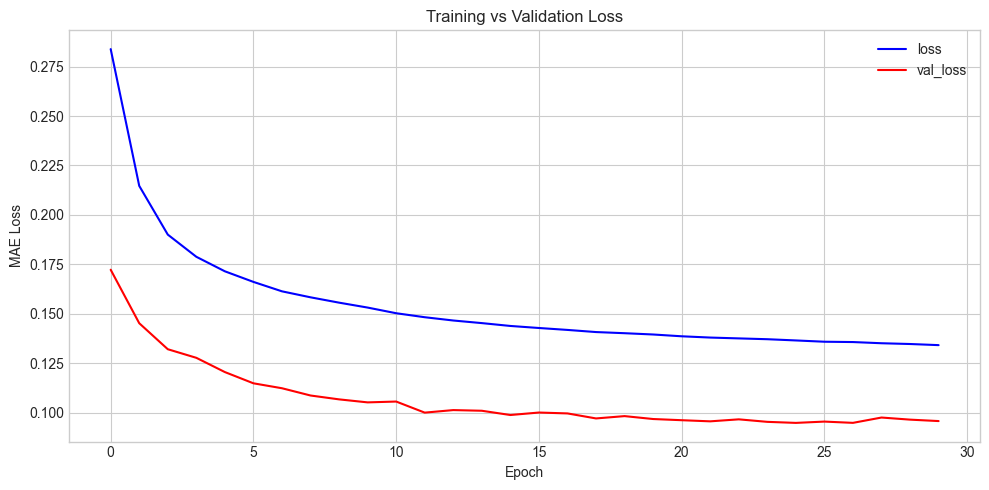

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='loss', color='blue')
plt.plot(history.history['val_loss'], label='val_loss', color='red')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=150)
plt.show()

## Prediction and Anomaly Threshold

In [20]:
x_pred = model.predict(sequences, batch_size=32, verbose=1)

mae_seq = np.mean(np.abs(sequences - x_pred), axis=1)
mae_per_sample = np.mean(mae_seq, axis=1)

threshold = mae_per_sample.mean() + 3 * mae_per_sample.std()
anomaly_flags = (mae_per_sample > threshold).astype(int)

print('Threshold:', round(float(threshold), 4))
print('Anomalies:', int(anomaly_flags.sum()))

1645/1645 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step
Threshold: 0.3309
Anomalies: 978


In [21]:
submission = pd.DataFrame({'is_anomaly': anomaly_flags})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved -> ONLY is_anomaly')

submission.csv saved -> ONLY is_anomaly


In [22]:
# Align result with sequence offset
result_df = df_plot.iloc[SEQ_LEN:].copy().reset_index(drop=True)
result_df['is_anomaly'] = anomaly_flags
result_df['mae'] = mae_per_sample

result_df.head()

,year,month,day,hour,Tpot,Tdew,rh,VPmax,VPact,VPdef,...,max..wv,wd,rain,raining,SWDR,PAR,max..PAR,Tlog,is_anomaly,mae
0,2020,Apr,92,10,276.62,-6.46,49.10,7.66,3.76,3.90,...,2.80,135.6,0.0,0.0,598.59,1126.83,1146.33,17.31,0,0.066285
1,2020,Apr,92,10,276.96,-6.70,47.07,7.84,3.69,4.15,...,2.94,125.4,0.0,0.0,617.10,1162.55,1180.31,17.87,0,0.066460
2,2020,Apr,92,10,277.19,-7.05,45.10,7.97,3.59,4.37,...,3.45,124.7,0.0,0.0,635.81,1199.03,1210.81,18.39,0,0.065672
3,2020,Apr,92,10,277.55,-6.97,44.30,8.16,3.62,4.55,...,2.84,75.3,0.0,0.0,649.50,1228.18,1246.91,18.86,0,0.064752
4,2020,Apr,92,10,278.03,-7.09,42.46,8.44,3.58,4.85,...,2.64,111.9,0.0,0.0,664.19,1256.95,1268.15,19.27,0,0.063214


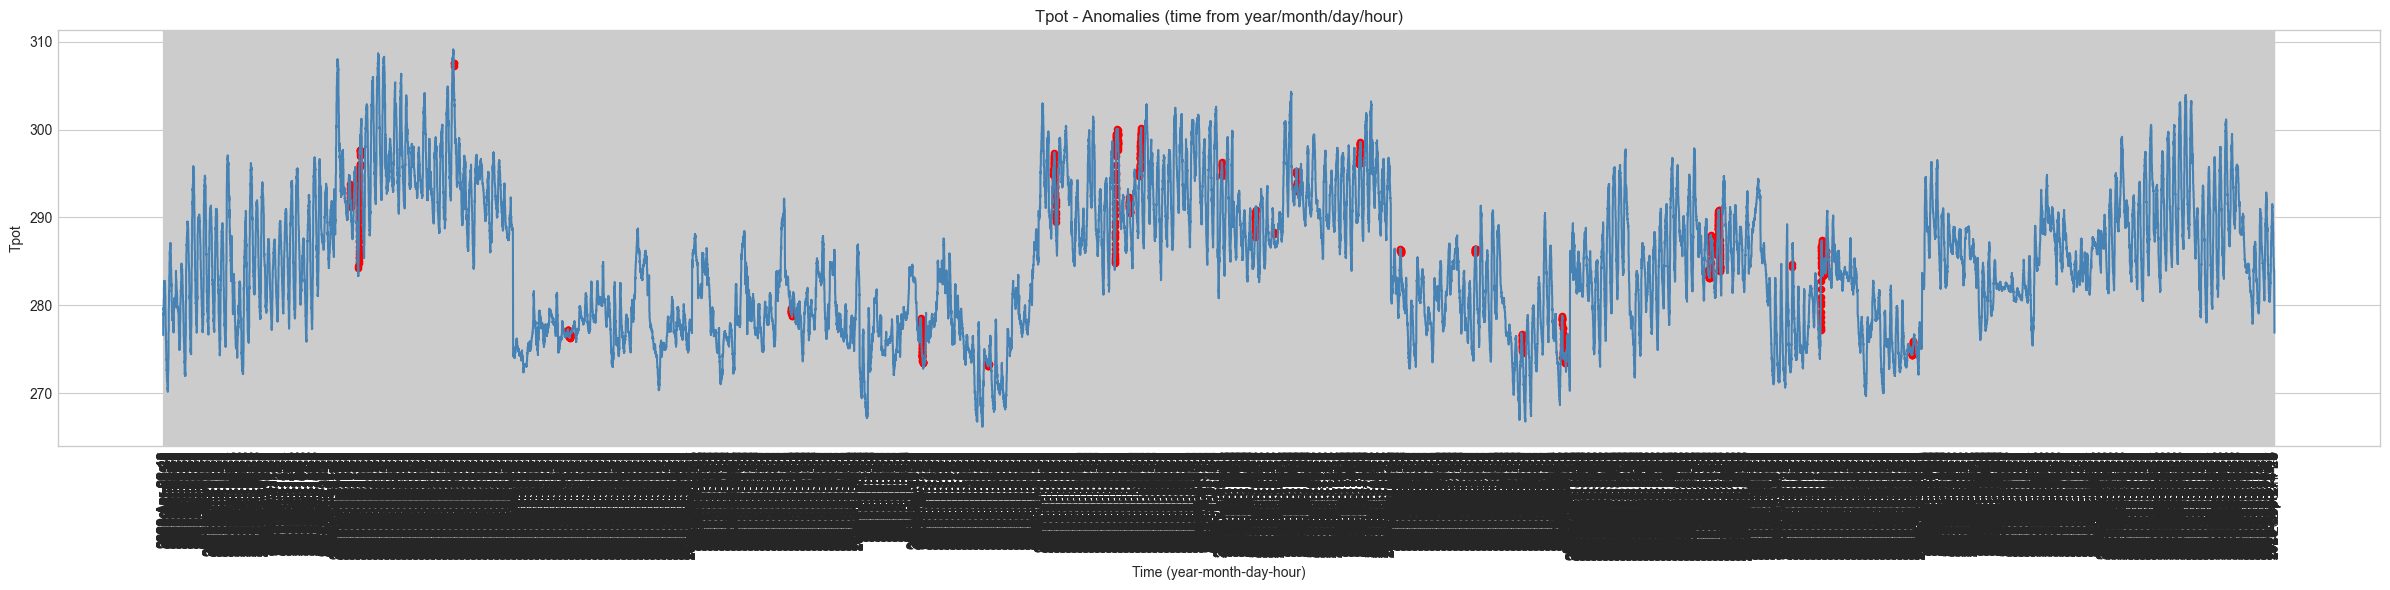

In [23]:
result_df['time_str'] = (
    result_df['year'].astype(str) + '-' +
    result_df['month'].astype(str) + '-' +
    result_df['day'].astype(str) + '-' +
    result_df['hour'].astype(str)
)

plt.figure(figsize=(24, 6))
plt.plot(result_df['time_str'], result_df['Tpot'], color='steelblue')
a = result_df[result_df['is_anomaly'] == 1]
plt.scatter(a['time_str'], a['Tpot'], color='red', s=20)
plt.title('Tpot - Anomalies (time from year/month/day/hour)')
plt.xlabel('Time (year-month-day-hour)')
plt.ylabel('Tpot')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Tpot_plot.png', dpi=150)
plt.show()

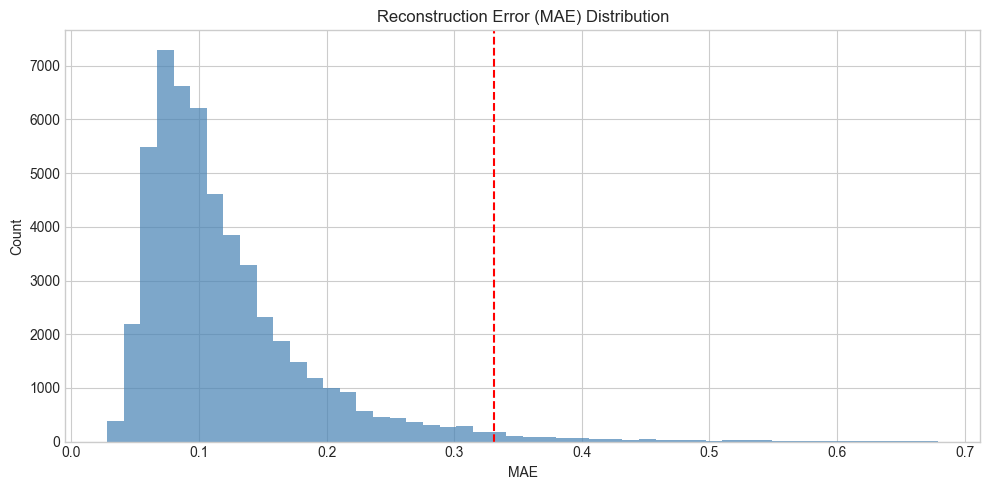

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(mae_per_sample, bins=50, color='steelblue', alpha=0.7)
plt.axvline(threshold, color='red', linewidth=1.5, linestyle='--')
plt.title('Reconstruction Error (MAE) Distribution')
plt.xlabel('MAE')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

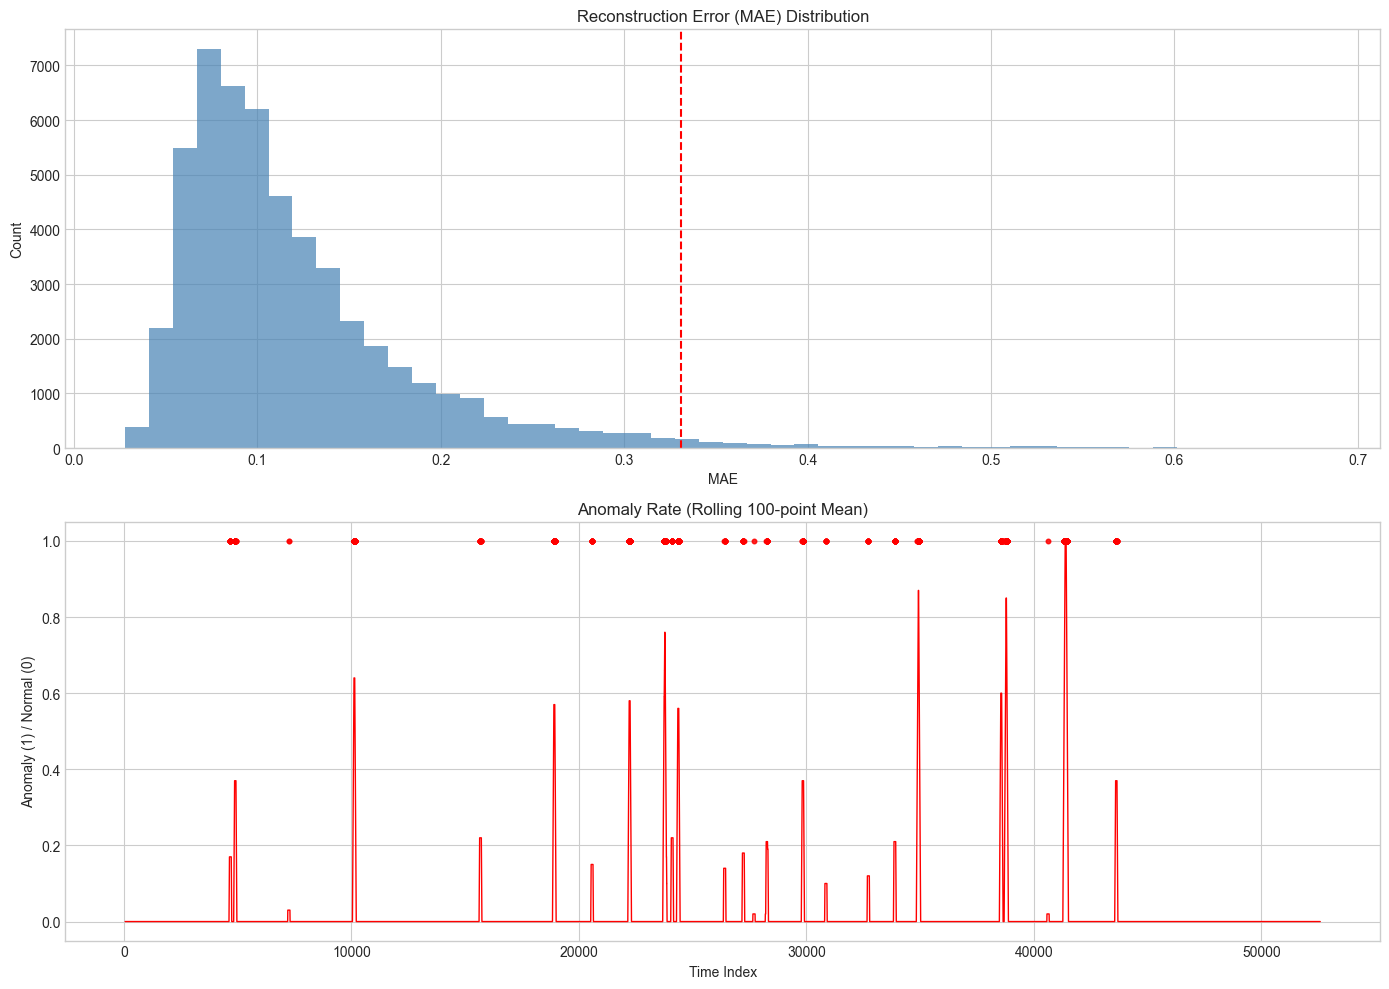

In [25]:
result_df = result_df.copy()
result_df['index'] = np.arange(1, len(result_df) + 1)
result_df['anomaly_roll'] = result_df['is_anomaly'].rolling(window=100, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].hist(mae_per_sample, bins=50, color='steelblue', alpha=0.7)
axes[0].axvline(threshold, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Reconstruction Error (MAE) Distribution')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Count')

axes[1].plot(result_df['index'], result_df['anomaly_roll'], color='red', linewidth=1)
a = result_df[result_df['is_anomaly'] == 1]
axes[1].scatter(a['index'], a['is_anomaly'], color='red', s=10, alpha=0.6)
axes[1].set_title('Anomaly Rate (Rolling 100-point Mean)')
axes[1].set_xlabel('Time Index')
axes[1].set_ylabel('Anomaly (1) / Normal (0)')

plt.tight_layout()
plt.savefig('evaluation_report.png', dpi=150)
plt.show()

In [26]:
top_anomalies = (
    result_df.sort_values('mae', ascending=False)
    .head(5)[['year', 'month', 'day', 'hour', 'Tpot', 'mae', 'is_anomaly']]
    .copy()
)
top_anomalies['mae'] = top_anomalies['mae'].round(4)

top_anomalies.to_csv('top_anomalies.csv', index=False)

print('=== TOP 5 ANOMALIES ===')
print(top_anomalies)

print('\n=== FINAL EVALUATION SUMMARY ===')
print('Total points:', len(result_df))
print('Anomalies detected:', int(anomaly_flags.sum()))
print('Anomaly rate:', round(100 * anomaly_flags.mean(), 3), '%')
print('Training time:', round(training_time, 2), 'seconds')
print('Threshold (MAE):', round(float(threshold), 4))
print('Model: LSTM Autoencoder (Python + TensorFlow/Keras)')

=== TOP 5 ANOMALIES ===
       year month  day  hour    Tpot     mae  is_anomaly
34916  2020   Mar   90    21  274.55  0.6795           1
34913  2020   Mar   90    21  274.25  0.6792           1
34915  2020   Mar   90    21  274.55  0.6790           1
34914  2020   Mar   90    21  274.34  0.6781           1
34912  2020   Mar   90    20  274.21  0.6771           1

=== FINAL EVALUATION SUMMARY ===
Total points: 52636
Anomalies detected: 978
Anomaly rate: 1.858 %
Training time: 3406.98 seconds
Threshold (MAE): 0.3309
Model: LSTM Autoencoder (Python + TensorFlow/Keras)


In [27]:
# Save threshold and stats for dashboard use
model_stats = pd.DataFrame({
    'threshold': [threshold],
    'total_points': [len(result_df)],
    'anomalies': [int(anomaly_flags.sum())],
    'anomaly_rate': [float(anomaly_flags.mean())]
})

model_stats.to_csv('model_stats.csv', index=False)
print('model_stats.csv saved!')

model_stats.csv saved!
